In [1]:
 %matplotlib inline
import matplotlib.pyplot as plt
import seaborn
 plt.style.use('seaborn')
import matplotlib as mpl
mpl.rcParams['font.family'] = 'serif'
import warnings; warnings.simplefilter('ignore')       #忽略警告信息；

C:\Users\admin\AppData\Local\Temp\ipykernel_36516\389051097.py:4: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


In [2]:
import pandas as pd
import numpy as np

In [3]:
import baostock as bs
lg = bs.login()

login success!


In [4]:
rs = bs.query_history_k_data_plus("sh.600000",
    "date,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST",
    start_date='2017-07-01', end_date='2017-12-31',
    frequency="d", adjustflag="3")
data_list = []
while (rs.error_code == '0') & rs.next():
    # 获取一条记录，将记录合并在一起
    data_list.append(rs.get_row_data())
data = pd.DataFrame(data_list, columns=rs.fields)


In [5]:
data.head()

,date,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST
0,2017-07-03,sh.600000,12.6400,12.6500,12.4700,12.5600,12.6500,38778949,486264672.0000,3,0.137985,1,-0.711456,0
1,2017-07-04,sh.600000,12.5500,12.5800,12.4100,12.5500,12.5600,36659128,458434432.0000,3,0.130442,1,-0.079620,0
2,2017-07-05,sh.600000,12.5000,12.6500,12.4700,12.6200,12.5500,26470507,332542464.0000,3,0.094188,1,0.557767,0
3,2017-07-06,sh.600000,12.6200,12.7200,12.5100,12.6600,12.6200,37414241,471582096.0000,3,0.133129,1,0.316957,0
4,2017-07-07,sh.600000,12.6200,12.6900,12.5500,12.6000,12.6600,24667294,311101536.0000,3,0.087772,1,-0.473929,0


In [6]:
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace = True) 
data.rename(columns={'close': 'price'}, inplace=True) 
data['price'] = list(map(float,data['price']))
data['volume'] = list(map(float,data['volume']))

In [7]:
data['returns'] = np.log(data['price'] / data['price'].shift(1))

In [8]:
data.dropna(inplace=True)

In [9]:
data.head()

,code,open,high,low,price,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST,returns
date,,,,,,,,,,,,,,
2017-07-04,sh.600000,12.5500,12.5800,12.4100,12.55,12.5600,36659128.0,458434432.0000,3,0.130442,1,-0.079620,0,-0.000796
2017-07-05,sh.600000,12.5000,12.6500,12.4700,12.62,12.5500,26470507.0,332542464.0000,3,0.094188,1,0.557767,0,0.005562
2017-07-06,sh.600000,12.6200,12.7200,12.5100,12.66,12.6200,37414241.0,471582096.0000,3,0.133129,1,0.316957,0,0.003165
2017-07-07,sh.600000,12.6200,12.6900,12.5500,12.60,12.6600,24667294.0,311101536.0000,3,0.087772,1,-0.473929,0,-0.004751
2017-07-10,sh.600000,12.5900,12.6400,12.5200,12.53,12.6000,26411530.0,331940512.0000,3,0.093979,1,-0.555561,0,-0.005571


<Axes: >

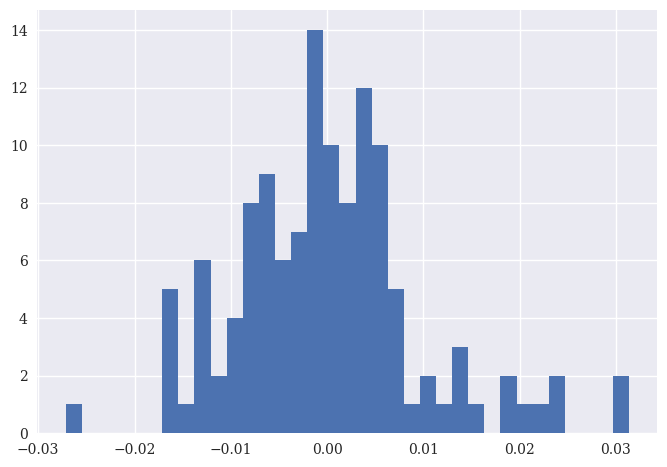

In [10]:
data['returns'].hist(bins=35)

In [11]:
total_dates = data.index.nunique()
split_index = int(total_dates * 0.7)

In [12]:
split_date = data.index.unique()[split_index]

In [13]:
train = data[:split_date]
test = data[split_date:]

In [14]:
train['position_10'] = np.sign(train['returns'].rolling(10).mean()) 

In [15]:
train['strategy_10'] = train['position_10'].shift(1) * train['returns']

In [16]:
train.head(20)

,code,open,high,low,price,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST,returns,position_10,strategy_10
date,,,,,,,,,,,,,,,,
2017-07-04,sh.600000,12.5500,12.5800,12.4100,12.55,12.5600,36659128.0,458434432.0000,3,0.130442,1,-0.079620,0,-0.000796,NaN,NaN
2017-07-05,sh.600000,12.5000,12.6500,12.4700,12.62,12.5500,26470507.0,332542464.0000,3,0.094188,1,0.557767,0,0.005562,NaN,NaN
2017-07-06,sh.600000,12.6200,12.7200,12.5100,12.66,12.6200,37414241.0,471582096.0000,3,0.133129,1,0.316957,0,0.003165,NaN,NaN
2017-07-07,sh.600000,12.6200,12.6900,12.5500,12.60,12.6600,24667294.0,311101536.0000,3,0.087772,1,-0.473929,0,-0.004751,NaN,NaN
2017-07-10,sh.600000,12.5900,12.6400,12.5200,12.53,12.6000,26411530.0,331940512.0000,3,0.093979,1,-0.555561,0,-0.005571,NaN,NaN
2017-07-11,sh.600000,12.5100,12.9400,12.5100,12.80,12.5300,96835349.0,1238626608.0000,3,0.344564,1,2.154832,0,0.021319,NaN,NaN
2017-07-12,sh.600000,12.8000,13.0600,12.7400,12.86,12.8000,80469025.0,1039614032.0000,3,0.286328,1,0.468746,0,0.004677,NaN,NaN
2017-07-13,sh.600000,12.8200,13.2900,12.7700,13.27,12.8600,110219238.0,1436784304.0000,3,0.392187,1,3.188187,0,0.031384,NaN,NaN
2017-07-14,sh.600000,13.3400,13.8000,13.3400,13.59,13.2700,146865370.0,1991795312.0000,3,0.522583,1,2.411452,0,0.023828,NaN,NaN


In [17]:
train.dropna(inplace=True)

In [18]:
train.head(10)

,code,open,high,low,price,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST,returns,position_10,strategy_10
date,,,,,,,,,,,,,,,,
2017-07-18,sh.600000,13.6500,13.7200,13.4000,13.55,13.7600,69895876.0,946717552.0000,3,0.248706,1,-1.526163,0,-0.015379,1.0,-0.015379
2017-07-19,sh.600000,13.5600,13.7800,13.4800,13.69,13.5500,66108709.0,900014400.0000,3,0.235231,1,1.033206,0,0.010279,1.0,0.010279
2017-07-20,sh.600000,13.6700,13.7000,13.5300,13.62,13.6900,40017492.0,544175216.0000,3,0.142392,1,-0.511320,0,-0.005126,1.0,-0.005126
2017-07-21,sh.600000,13.6100,13.6300,13.3800,13.45,13.6200,52272375.0,702999232.0000,3,0.185998,1,-1.248165,0,-0.012560,1.0,-0.012560
2017-07-24,sh.600000,13.4500,13.7400,13.3600,13.67,13.4500,65820954.0,892033680.0000,3,0.234207,1,1.635690,0,0.016225,1.0,0.016225
2017-07-25,sh.600000,13.6200,13.7500,13.4100,13.51,13.6700,58478099.0,795769072.0000,3,0.208079,1,-1.170445,0,-0.011773,1.0,-0.011773
2017-07-26,sh.600000,13.4500,13.7000,13.3600,13.38,13.5100,57495388.0,775489072.0000,3,0.204583,1,-0.962251,0,-0.009669,1.0,-0.009669
2017-07-27,sh.600000,13.3800,13.4700,13.2800,13.38,13.3800,33612097.0,449548320.0000,3,0.119600,1,0.000000,0,0.000000,1.0,0.000000
2017-07-28,sh.600000,13.3700,13.4900,13.3000,13.47,13.3800,24954961.0,334111568.0000,3,0.088796,1,0.672647,0,0.006704,-1.0,0.006704


<Axes: title={'center': 'Market Positioning'}, xlabel='date'>

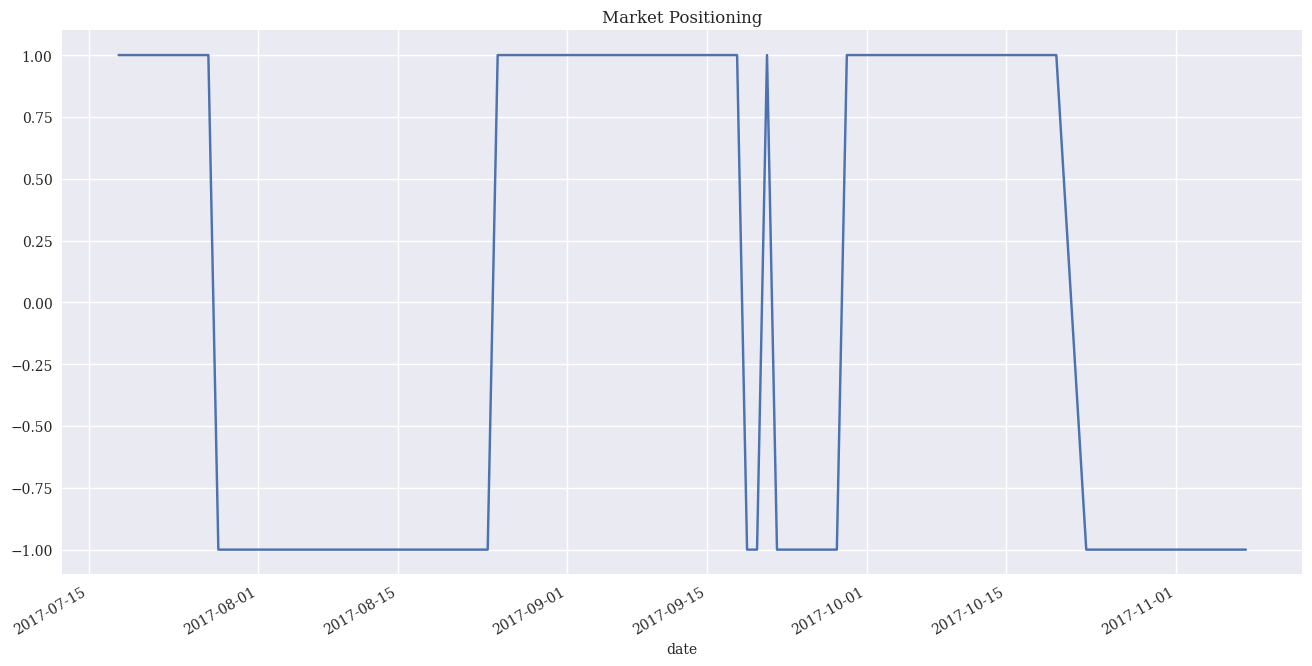

In [19]:
train['position_10'].plot(ylim=[-1.1, 1.1], figsize=(16,8),title='Market Positioning')

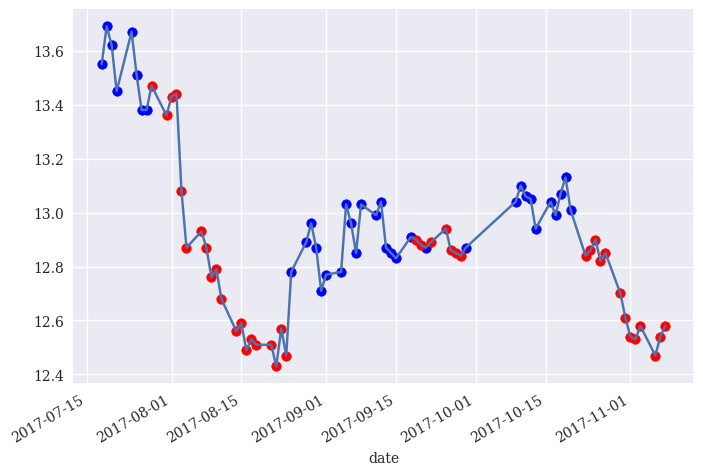

In [20]:
buy = train[train['position_10'] == 1]
sell = train[train['position_10'] == -1]
train['price'].plot()
plt.scatter(buy.index, buy['price'], color='blue') 
plt.scatter(sell.index, sell['price'], color='red') 

<Axes: xlabel='date'>

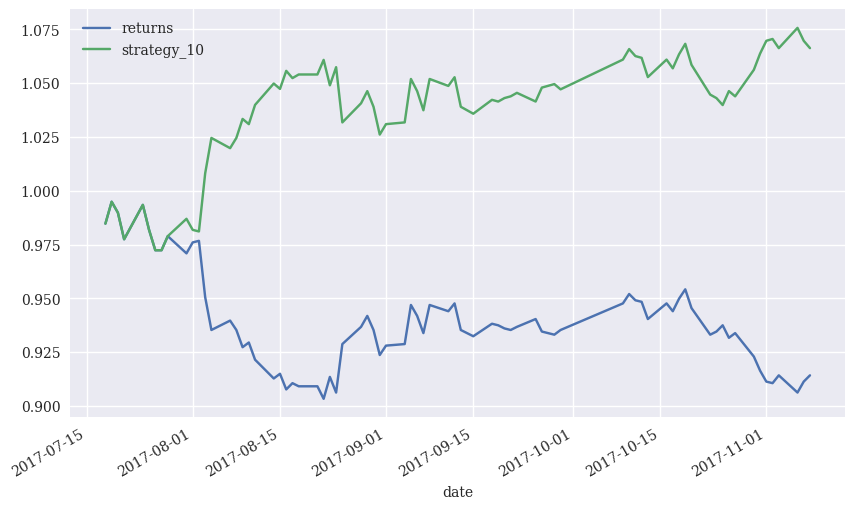

In [21]:
train[['returns', 'strategy_10']].cumsum().apply(np.exp).plot(figsize=(10, 6))    

In [22]:
train[['returns', 'strategy_10']].mean()

returns       -0.001164
strategy_10    0.000834
dtype: float64

In [23]:
train[['returns', 'strategy_10']].std()

returns        0.008616
strategy_10    0.008655
dtype: float64

In [24]:
train[['returns', 'strategy_10']].mean()/ train[['returns', 'strategy_10']].std()

returns       -0.135140
strategy_10    0.096313
dtype: float64

<Axes: xlabel='date'>

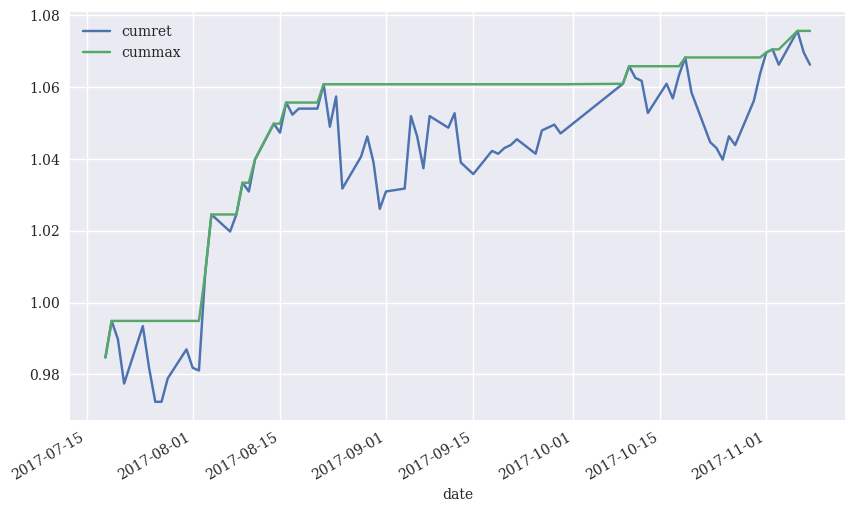

In [25]:
train['cumret'] =train['strategy_10'].cumsum().apply(np.exp)
train['cummax'] = train['cumret'].cummax()
train[['cumret', 'cummax']].plot(figsize=(10, 6))

In [26]:
traindrawdown = (train['cummax'] - train['cumret'])
traindrawdown.max()

0.03470381532985889